In [1]:
from datasets import load_dataset

/opt/miniconda3/envs/wolverines/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset('kdoherty/wolverines', split='train')

Generating train split: 2076 examples [00:02, 813.51 examples/s]
Generating test split: 597 examples [00:00, 1087.51 examples/s]


In [3]:
ds

Dataset({
    features: ['image', 'group', 'species', 'id', 'station', 'year', 'color', 'marks', 'ymdh', 'label'],
    num_rows: 2076
})

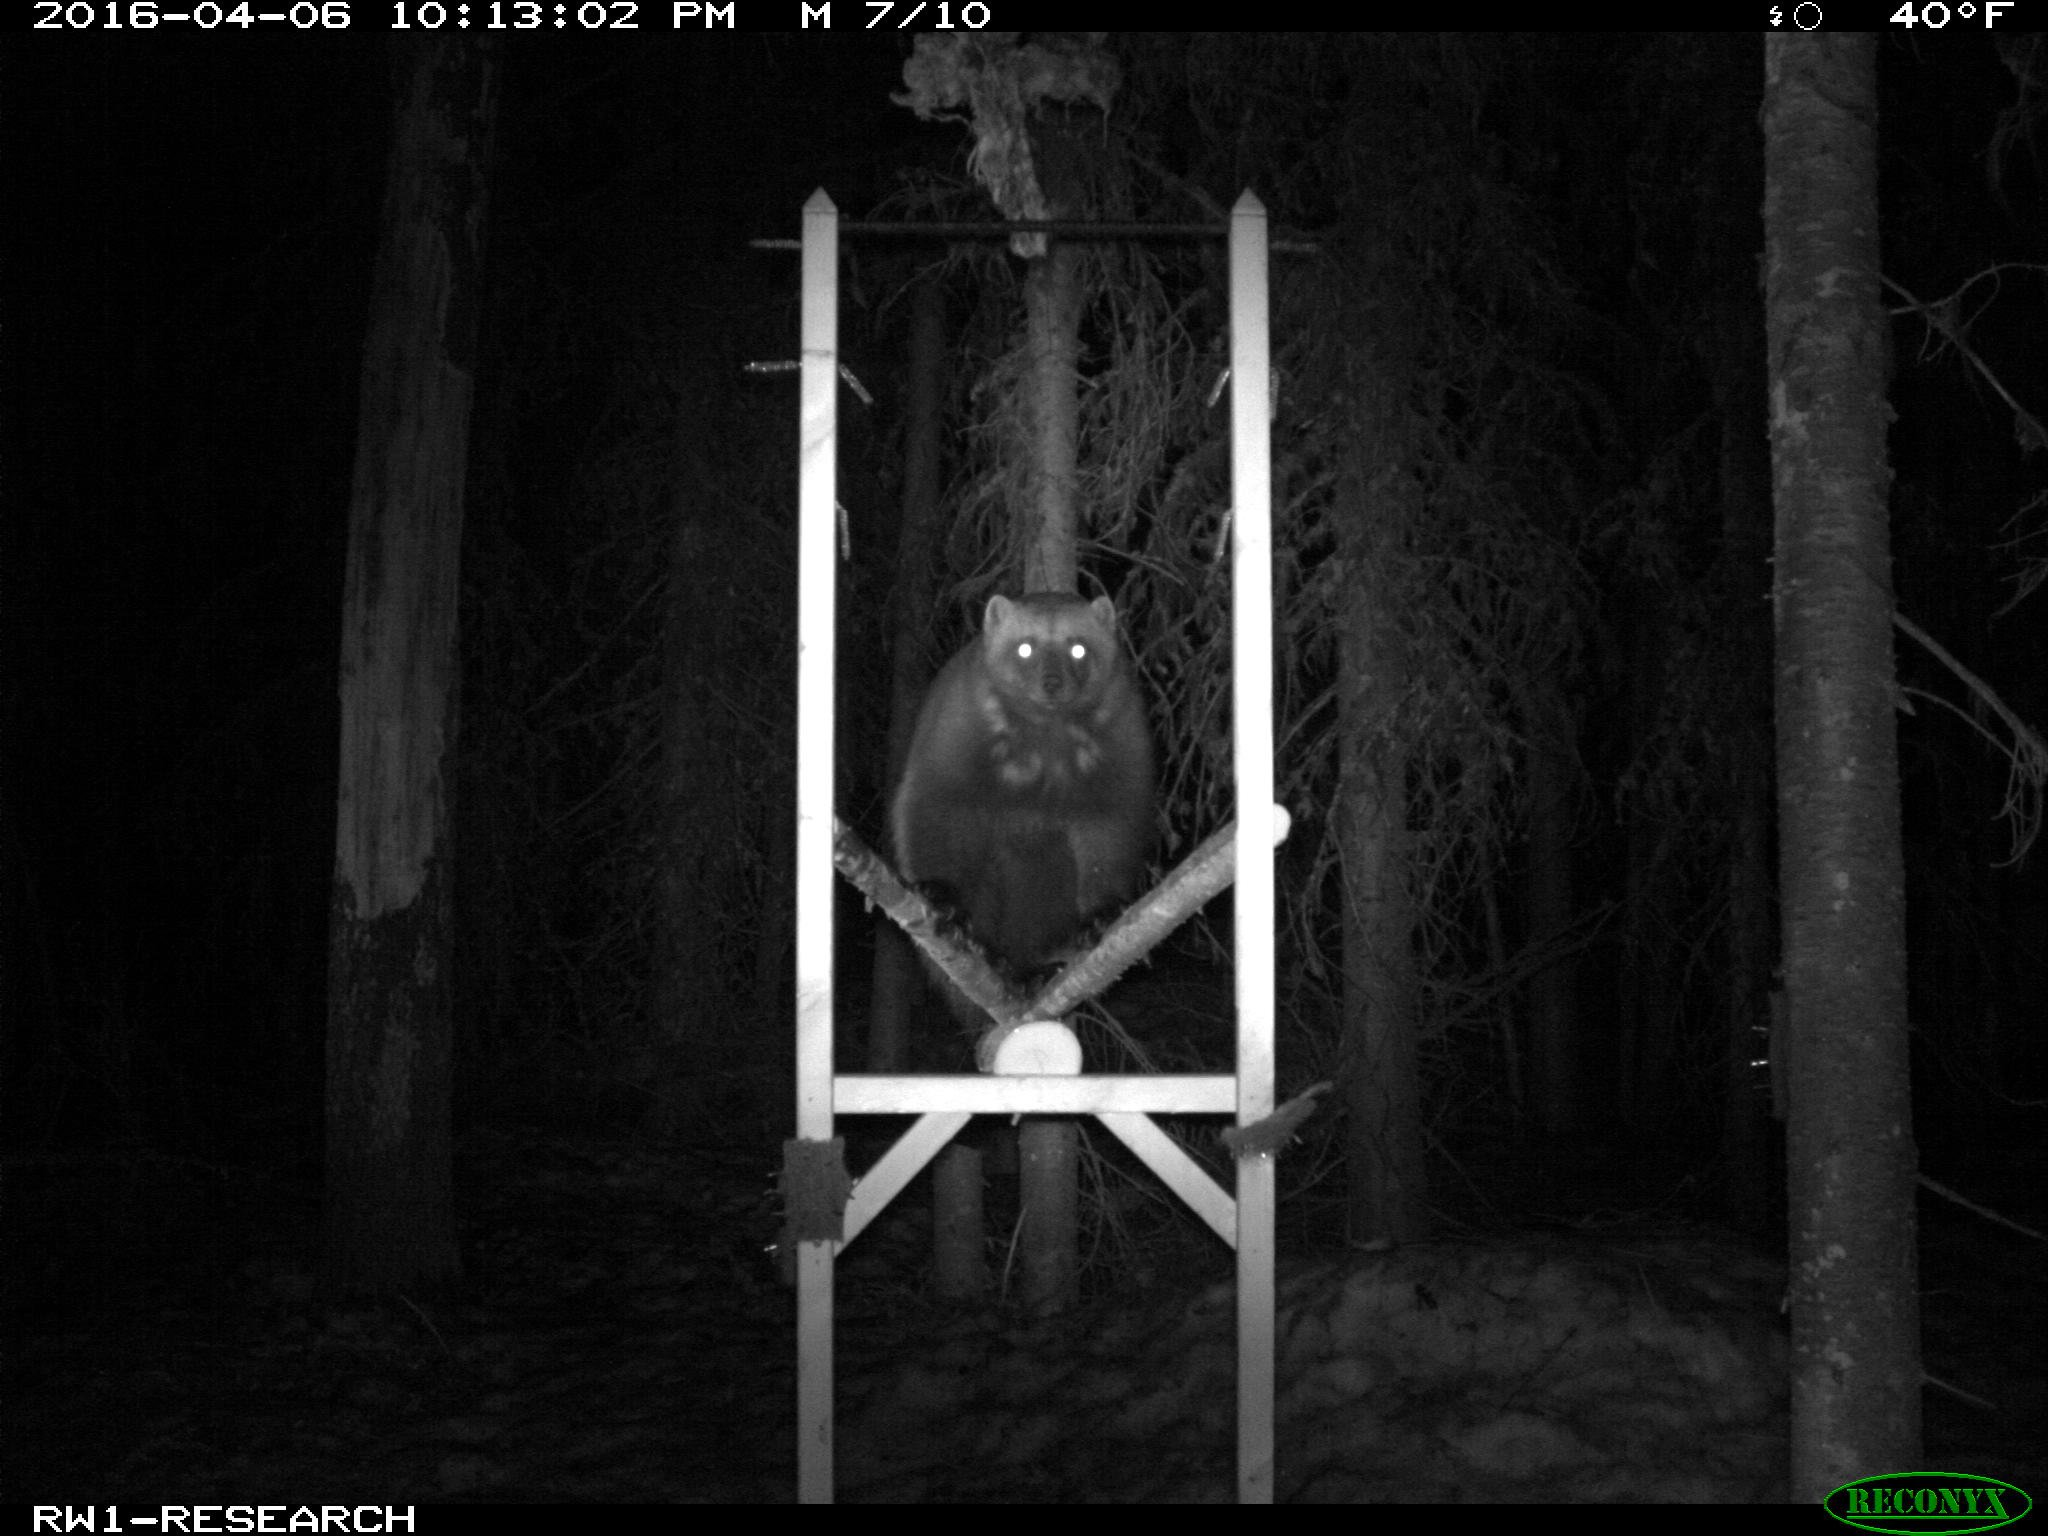

In [7]:
ds[1]['label'], ds[1]['marks']
ds[1]['image']

In [13]:
import torch
import os
from PytorchWildlife.models import detection as pw_detection

# Create cache directory if it doesn't exist
cache_dir = os.path.expanduser('~/.cache/torch/hub')
os.makedirs(cache_dir, exist_ok=True)

# Download weights directly using torch.hub
checkpoint_url = "https://github.com/microsoft/CameraTraps/releases/download/v6.0.0/md_v6.0.0.pt"
try:
    checkpoint = torch.hub.load_state_dict_from_url(
        checkpoint_url,
        model_dir=cache_dir,
        map_location=torch.device('cpu')
    )
    print("Successfully downloaded weights")
except Exception as e:
    print(f"Error downloading weights: {e}")

# Now try loading the model
detection_model = pw_detection.MegaDetectorV6(pretrained=True)

Downloading: "https://github.com/microsoft/CameraTraps/releases/download/v6.0.0/md_v6.0.0.pt" to /Users/kdoherty/.cache/torch/hub/md_v6.0.0.pt


Error downloading weights: HTTP Error 404: Not Found


FileNotFoundError: [Errno 2] No such file or directory: '/Users/kdoherty/ (1).cache/torch/hub/checkpoints'